In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [79]:
df = pd.read_csv(
    r"C:\Users\norie\Documents\Machine Learning\Projects\intel-daily-stock-price-prediction\data\cleaned\intel-daily-stock-price-data-cleaned.csv"
)

In [43]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends
0,2021-04-01,58.863657,59.018273,57.826813,58.709042,31416300,0.0
1,2021-04-05,59.072846,60.700874,58.845467,60.518974,27947500,0.0
2,2021-04-06,60.082411,60.555362,59.382090,59.627655,28771400,0.0
3,2021-04-07,59.727696,60.546258,59.445749,60.255215,17793300,0.0
4,2021-04-08,60.910064,61.201107,60.355260,60.982826,22224200,0.0


In [44]:
df.tail()

,Date,Open,High,Low,Close,Volume,Dividends
1270,2026-04-23,66.099998,68.279999,65.419998,66.779999,155141800,0.0
1271,2026-04-24,82.199997,85.220001,79.620003,82.540001,281405200,0.0
1272,2026-04-27,83.669998,87.099998,82.610001,84.989998,178820200,0.0
1273,2026-04-28,81.279999,84.589996,80.800003,84.519997,147773500,0.0
1274,2026-04-29,86.139999,94.949997,85.870003,94.750000,235070900,0.0


In [45]:
df.shape

(1275, 7)

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1275 non-null   str    
 1   Open       1275 non-null   float64
 2   High       1275 non-null   float64
 3   Low        1275 non-null   float64
 4   Close      1275 non-null   float64
 5   Volume     1275 non-null   int64  
 6   Dividends  1275 non-null   float64
dtypes: float64(5), int64(1), str(1)
memory usage: 69.9 KB


In [47]:
df.describe()

,Open,High,Low,Close,Volume,Dividends
count,1275.000000,1275.000000,1275.000000,1275.000000,1.275000e+03,1275.000000
mean,35.646336,36.224236,35.085249,35.659753,5.882146e+07,0.002838
std,11.094325,11.259121,10.970599,11.155774,4.490919e+07,0.029556
min,18.070000,18.990000,17.670000,18.129999,1.131490e+07,0.000000
25%,25.959999,26.343883,25.468109,25.865690,3.133445e+07,0.000000
50%,34.481264,35.043890,33.956170,34.559002,4.456490e+07,0.000000
75%,44.679943,45.533819,44.075556,44.792091,7.086970e+07,0.000000
max,86.139999,94.949997,85.870003,94.750000,5.239080e+08,0.365000


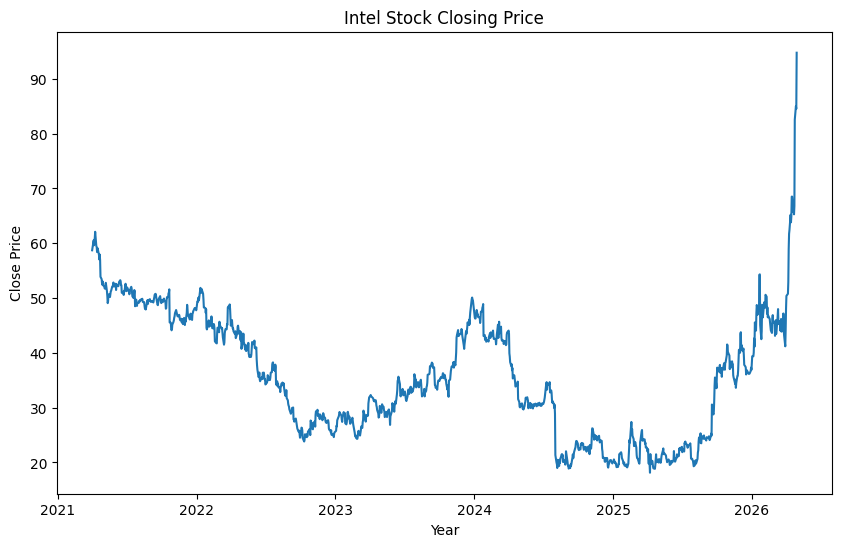

In [49]:
import matplotlib.dates as mdates

# Make sure Date column is datetime
df["Date"] = pd.to_datetime(df["Date"])

plt.figure(figsize=(10,6))

plt.plot(df["Date"], df["Close"])

plt.title("Intel Stock Closing Price")
plt.xlabel("Year")
plt.ylabel("Close Price")

plt.show()

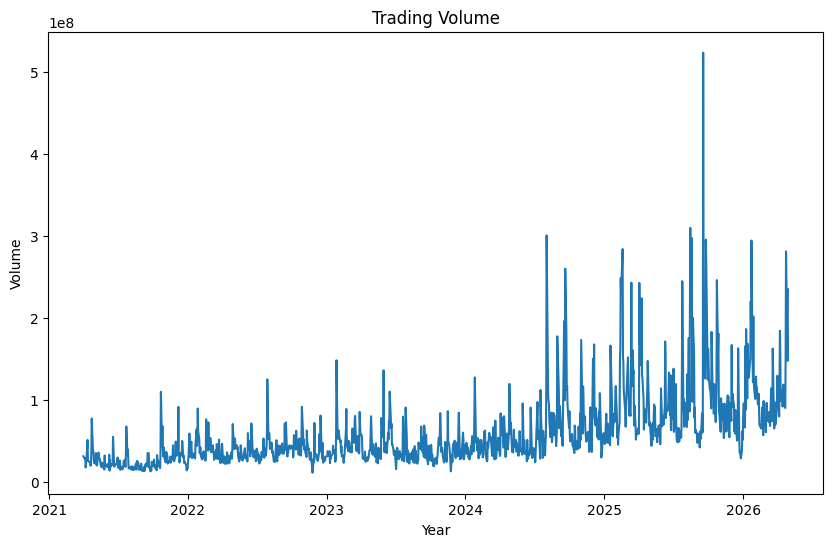

In [50]:
plt.figure(figsize=(10,6))

plt.plot(df["Date"], df["Volume"])

plt.title("Trading Volume")
plt.xlabel("Year")
plt.ylabel("Volume")

plt.show()

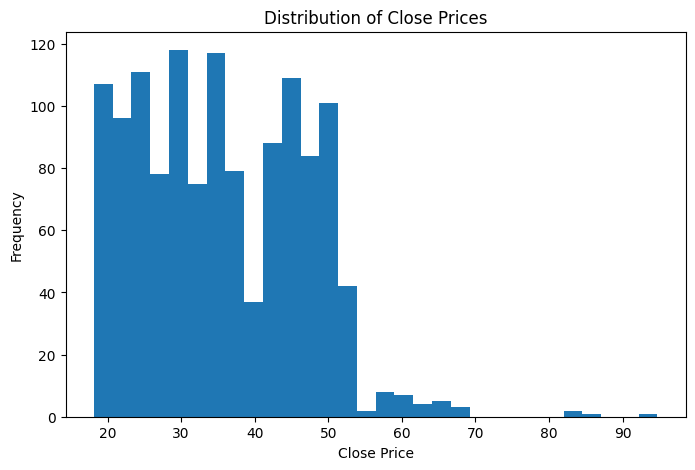

In [34]:
plt.figure(figsize=(8,5))

plt.hist(df["Close"], bins=30)

plt.title("Distribution of Close Prices")
plt.xlabel("Close Price")
plt.ylabel("Frequency")

plt.show()

In [80]:
df["MA5"] = df["Close"].rolling(window=5).mean()

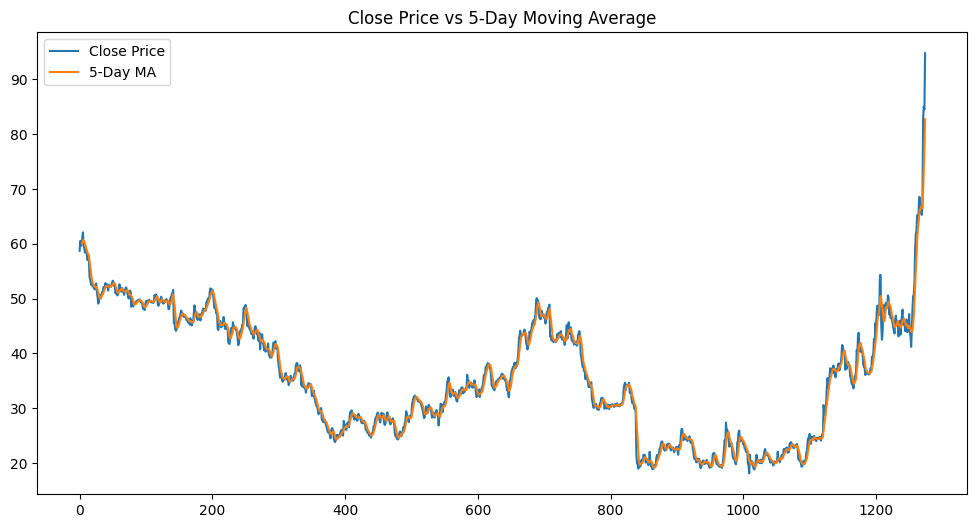

In [81]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Close"], label="Close Price")
plt.plot(df.index, df["MA5"], label="5-Day MA")

plt.title("Close Price vs 5-Day Moving Average")

plt.legend()

plt.show()

In [82]:
df["MA14"] = df["Close"].rolling(window=14).mean()

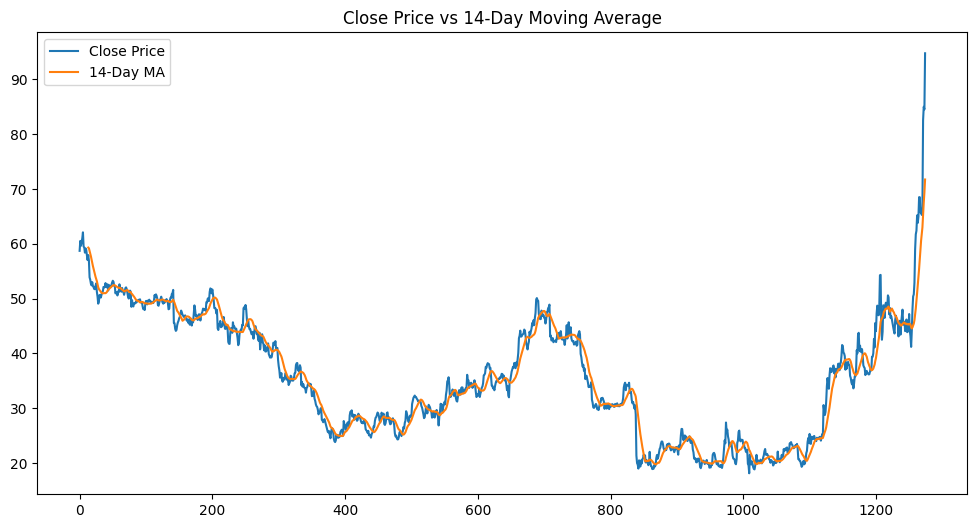

In [83]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Close"], label="Close Price")
plt.plot(df.index, df["MA14"], label="14-Day MA")

plt.title("Close Price vs 14-Day Moving Average")

plt.legend()

plt.show()

In [84]:
df["Daily_Return"] = df["Close"].pct_change()

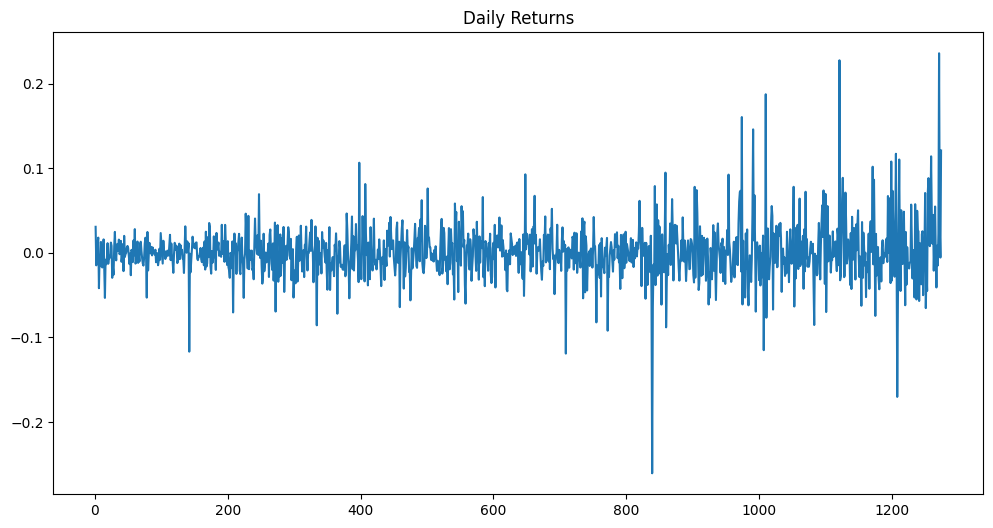

In [85]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Daily_Return"])

plt.title("Daily Returns")

plt.show()

In [86]:
volatility = df["Daily_Return"].std()

print("Volatility:", volatility)

Volatility: 0.031561652382986805


In [87]:
print("Highest Close Price:", df["Close"].max())

print("Lowest Close Price:", df["Close"].min())

Highest Close Price: 94.75
Lowest Close Price: 18.1299991607666


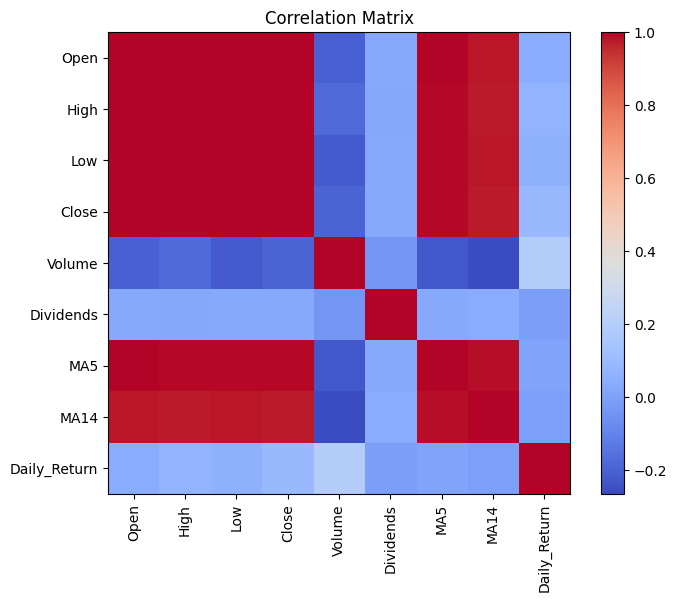

In [88]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

plt.imshow(corr, cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()